# Proyecto Aprendizaje de Máquina 2026-20
## Parte 1 — Clasificación de sentimiento de reseñas en español

**Estudiante:** Santiago Serrano

### Objetivo

Construir un sistema clásico de aprendizaje automático capaz de clasificar una reseña de producto escrita en español como:

- `negativo`
- `neutral`
- `positivo`

En esta primera parte se utilizarán exclusivamente técnicas clásicas de `scikit-learn`, principalmente:

- TF-IDF
- n-gramas de palabras
- n-gramas de caracteres
- Logistic Regression
- Linear SVM
- Naive Bayes

No se utilizan redes neuronales, transformers ni embeddings neuronales preentrenados.

### Metodología general

1. Revisar la calidad de los datos.
2. Separar `train.csv` en entrenamiento y validación.
3. Construir varios modelos clásicos.
4. Compararlos con la métrica oficial: **accuracy**.
5. Generar diferentes archivos de envío para Kaggle.
6. Registrar los resultados de Kaggle.
7. Seleccionar el mejor modelo.
8. Reentrenarlo con los 12.000 ejemplos.
9. Guardar el pipeline completo con `joblib`.


# 1. Librerías

Se importan herramientas para procesamiento de texto, clasificación, validación y almacenamiento del modelo final.


In [54]:
from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 180)

RANDOM_STATE = 42


# 2. Carga de datos

El notebook funciona tanto si los CSV están dentro de `data/` como si están en la misma carpeta del notebook.

`eval.csv` **no se utiliza para entrenamiento ni para seleccionar modelos**. Solo se usa al generar los archivos de predicción para Kaggle.


In [55]:
DATA_DIR = Path("data")

if not (DATA_DIR / "train.csv").exists():
    DATA_DIR = Path(".")

TRAIN_PATH = DATA_DIR / "train.csv"
EVAL_PATH = DATA_DIR / "eval.csv"
SAMPLE_PATH = DATA_DIR / "sample_submission.csv"

print("Carpeta de datos:", DATA_DIR.resolve())
print("train existe:", TRAIN_PATH.exists())
print("eval existe:", EVAL_PATH.exists())
print("sample existe:", SAMPLE_PATH.exists())

train = pd.read_csv(TRAIN_PATH)
eval_df = pd.read_csv(EVAL_PATH)
sample_submission = pd.read_csv(SAMPLE_PATH)

print("\nDimensiones:")
print("Train:", train.shape)
print("Eval:", eval_df.shape)
print("Sample submission:", sample_submission.shape)

display(train.head())
display(eval_df.head())
display(sample_submission.head())


Carpeta de datos: /Users/santiagoserranoperico/Desktop/Universidad/2026-2/aprendizaje/proyecto/PROYECTO-AM-GRUPO20/data
train existe: True
eval existe: True
sample existe: True

Dimensiones:
Train: (12000, 3)
Eval: (3000, 2)
Sample submission: (3000, 2)


,id,text,label
0,0,"Lo pedí un martes por la noche y me llegó al día siguiente. Es el modelo en color negro, el básico de la línea. Lo pesé en la báscula de la cocina y marca algo más de medio kil...",neutral
1,1,"Se lo compré a un familiar después de pensarla varias semanas, llegó en unos cuatro días a mi casa. La verdad sea dicha, el soporte técnico me resultó incumplidor para lo que n...",positivo
2,2,"Lo pedí a mediados de mes y me llegó en tres días, en su caja normal sin nada fuera de lo común. Lo uso en la oficina casi a diario desde entonces. El diseño se sintió durable ...",negativo
3,3,"Compré esto en línea y llegó en unos tres días a la casa. Venían varias unidades en el paquete, revisé todas una por una. El ensamblaje terminó siendo impreciso para lo que nec...",negativo
4,4,"Compré este kit el mes pasado porque necesitaba algo para las videollamadas del trabajo, llegó en tres días a casa. La verdad, el cargador me pareció terrible para mi gusto. Lo...",positivo


,id,text
0,0,"Hice el pedido desde la aplicacion un martes por la tarde y llego a mi casa al dia siguiente. El paquete venia bien cerrado y, de paquete, traia ademas una bolsa de tela. Esa b..."
1,1,"Compre esto a principios de mes porque andaba necesitando uno, llego en unos cuantos dias a mi casa. Al principio el rendimiento me parecio flojo tras el primer mes, la verdad ..."
2,2,"Lo pedí un martes y me llegó el jueves a la casa. Lo compré para reemplazar uno anterior que ya tenía en el cuarto de baño. Viene en cuatro tamaños distintos, así que alcanza p..."
3,3,"Me llegó el miércoles pasado, tres días después de hacer el pedido. Lo pruebo casi a diario desde hace poco, nomás lo saco un rato en las tardes. Mide como veinte centímetros y..."
4,4,"Lo pedí un martes y llegó el jueves a la casa. En el paquete venían dos unidades, tal cual. Las medidas coinciden con lo que dice la descripción. Las medí con una cinta métrica..."


,id,answer
0,0,neutral
1,1,neutral
2,2,neutral
3,3,neutral
4,4,neutral


# 3. Revisión rápida de los datos

Antes de modelar se revisan:

- nombres de columnas;
- valores faltantes;
- duplicados;
- distribución de clases;
- longitud aproximada de las reseñas.

No se hará una limpieza agresiva del texto. Palabras como `no`, `nunca`, `pero` o `aunque` pueden ser importantes para el sentimiento, por lo que no se eliminan stopwords.


In [56]:
print("Columnas de train:", train.columns.tolist())
print("Columnas de eval:", eval_df.columns.tolist())

print("\nNulos en train:")
display(train.isnull().sum())

print("\nNulos en eval:")
display(eval_df.isnull().sum())

print("\nFilas duplicadas en train:", train.duplicated().sum())
print("IDs duplicados en train:", train["id"].duplicated().sum())
print("Textos duplicados en train:", train["text"].duplicated().sum())

print("\nDistribución de clases:")
display(train["label"].value_counts())

print("\nDistribución porcentual:")
display(
    (train["label"].value_counts(normalize=True) * 100)
    .round(2)
    .rename("porcentaje")
)


Columnas de train: ['id', 'text', 'label']
Columnas de eval: ['id', 'text']

Nulos en train:


id       0
text     0
label    0
dtype: int64


Nulos en eval:


id      0
text    0
dtype: int64


Filas duplicadas en train: 0
IDs duplicados en train: 0
Textos duplicados en train: 0

Distribución de clases:


label
positivo    4212
negativo    4212
neutral     3576
Name: count, dtype: int64


Distribución porcentual:


label
positivo    35.1
negativo    35.1
neutral     29.8
Name: porcentaje, dtype: float64

,count,mean,median,min,max
label,,,,,
negativo,4212,283.68,284.0,28,528
neutral,3576,270.99,270.0,14,517
positivo,4212,287.90,286.0,25,579


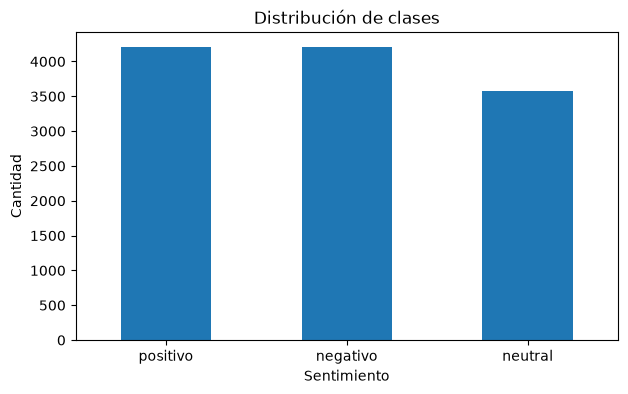

In [57]:
train["longitud"] = train["text"].astype(str).str.len()

display(
    train.groupby("label")["longitud"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

plt.figure(figsize=(7, 4))
train["label"].value_counts().plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()


In [58]:
for clase in ["negativo", "neutral", "positivo"]:
    print("\n" + "=" * 70)
    print("EJEMPLOS DE CLASE:", clase.upper())
    print("=" * 70)

    ejemplos = (
        train.loc[train["label"] == clase, "text"]
        .sample(n=3, random_state=RANDOM_STATE)
    )

    for texto in ejemplos:
        print("-", texto)



EJEMPLOS DE CLASE: NEGATIVO
- La compré en noviembre en una oferta del buen fin, llegó en cuatro días. En pocas palabras, la cámara no es para nada lo que esperaba. La uso nomás para fotos casuales en casa. Además, la interfaz fue todo un acierto, la uso a diario y la dejo igual que cuando llegó.
- Lo compre hace poco por internet porque queria reemplazar uno viejo que tenia en la casa. Me llego en unos trs dias. La autonoia me salio eficiente para lo que necesitaba, la uso a diario en las mananas. Eso si, el tamano es de mala calidad hasta ahora.
- Llevo ya un rato con él, lo compré para usar en la cocina de mi casa y llegó en tres días. En mi opinión el material quedó sólido en general, se siente firme al tocarlo. La duración de la carga terminó siendo mal hecha desde el primer día, y eso que seguí las instrucciones de uso.

EJEMPLOS DE CLASE: NEUTRAL
- Lo pedí un martes por la tarde porque justo andaba cerca de la oficina donde lo iba a usar. Llegó en menos de tres días, o sea que 

# 4. Preparación de entrenamiento y validación

Se conserva un 20% de `train.csv` como validación interna.

Se utiliza `stratify=y` para mantener aproximadamente la misma distribución de sentimientos en entrenamiento y validación.

El archivo `eval.csv` permanece completamente separado.


In [59]:
X = train["text"].fillna("").astype(str)
y = train["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Validación:", X_val.shape)

print("\nDistribución train:")
display(y_train.value_counts(normalize=True).round(3))

print("\nDistribución validación:")
display(y_val.value_counts(normalize=True).round(3))


Entrenamiento: (9600,)
Validación: (2400,)

Distribución train:


label
positivo    0.351
negativo    0.351
neutral     0.298
Name: proportion, dtype: float64


Distribución validación:


label
negativo    0.351
positivo    0.351
neutral     0.298
Name: proportion, dtype: float64

# 5. Funciones auxiliares

Para que todos los experimentos se evalúen de la misma manera se crean dos funciones:

- `evaluar_modelo`: entrena en `X_train` y evalúa en `X_val`.
- `crear_submission`: clona el modelo, lo reentrena con los 12.000 ejemplos y genera el CSV para Kaggle.

De esta manera las predicciones de `eval.csv` nunca participan en la selección del modelo.


In [60]:
resultados = []
modelos = {}


def evaluar_modelo(nombre, representacion, modelo):
    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_val)
    accuracy = accuracy_score(y_val, pred)

    resultados.append({
        "Experimento": nombre,
        "Representación": representacion,
        "Modelo": modelo.named_steps.get(
            "modelo",
            modelo.named_steps.get("clasificador", "pipeline")
        ).__class__.__name__,
        "Accuracy_validación": accuracy
    })

    modelos[nombre] = modelo

    print("=" * 70)
    print(nombre)
    print("Accuracy validación:", round(accuracy, 5))
    print("=" * 70)
    print(classification_report(y_val, pred))

    return accuracy, pred


def crear_submission(nombre, modelo):
    carpeta = Path("submissions")
    carpeta.mkdir(exist_ok=True)

    modelo_full = clone(modelo)
    modelo_full.fit(X, y)

    pred_eval = modelo_full.predict(
        eval_df["text"].fillna("").astype(str)
    )

    submission = pd.DataFrame({
        "id": eval_df["id"],
        "answer": pred_eval
    })

    assert len(submission) == len(eval_df)
    assert submission["id"].is_unique
    assert submission["answer"].isin(
        ["negativo", "neutral", "positivo"]
    ).all()

    ruta = carpeta / f"{nombre}.csv"
    submission.to_csv(ruta, index=False)

    print("Submission creada:", ruta)
    display(submission.head())

    return modelo_full, ruta


# 6. Experimento 1 — TF-IDF unigramas + Logistic Regression

Este modelo funciona como baseline interno.

TF-IDF asigna mayor peso a términos informativos y reduce el peso de palabras muy frecuentes.


In [61]:
modelo_1 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 1)
        )
    ),
    (
        "modelo",
        LogisticRegression(
            max_iter=2500,
            random_state=RANDOM_STATE
        )
    )
])

accuracy_1, pred_1 = evaluar_modelo(
    "exp01_logreg_unigram",
    "TF-IDF palabras (1,1)",
    modelo_1
)


exp01_logreg_unigram
Accuracy validación: 0.7275
              precision    recall  f1-score   support

    negativo       0.62      0.61      0.62       843
     neutral       0.96      1.00      0.98       715
    positivo       0.62      0.61      0.62       842

    accuracy                           0.73      2400
   macro avg       0.74      0.74      0.74      2400
weighted avg       0.72      0.73      0.73      2400



# 7. Experimento 2 — TF-IDF unigramas + bigramas + Logistic Regression

Los bigramas permiten representar expresiones como:

- `no funciona`
- `muy bueno`
- `mala calidad`

Esto puede ser útil para sentimiento porque una palabra aislada no siempre conserva el significado de la frase.


In [62]:
modelo_2 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LogisticRegression(
            C=2.0,
            max_iter=2500,
            random_state=RANDOM_STATE
        )
    )
])

accuracy_2, pred_2 = evaluar_modelo(
    "exp02_logreg_bigram",
    "TF-IDF palabras (1,2)",
    modelo_2
)


exp02_logreg_bigram
Accuracy validación: 0.72833
              precision    recall  f1-score   support

    negativo       0.62      0.61      0.62       843
     neutral       0.98      1.00      0.99       715
    positivo       0.62      0.61      0.62       842

    accuracy                           0.73      2400
   macro avg       0.74      0.74      0.74      2400
weighted avg       0.73      0.73      0.73      2400



# 8. Experimento 3 — TF-IDF de palabras + LinearSVC

`LinearSVC` es un clasificador lineal especialmente adecuado para matrices dispersas de alta dimensionalidad como las producidas por TF-IDF.


In [63]:
modelo_3 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LinearSVC(
            C=1.0,
            random_state=RANDOM_STATE
        )
    )
])

accuracy_3, pred_3 = evaluar_modelo(
    "exp03_svc_word",
    "TF-IDF palabras (1,2)",
    modelo_3
)


exp03_svc_word
Accuracy validación: 0.72375
              precision    recall  f1-score   support

    negativo       0.61      0.61      0.61       843
     neutral       0.98      1.00      0.99       715
    positivo       0.61      0.61      0.61       842

    accuracy                           0.72      2400
   macro avg       0.73      0.74      0.74      2400
weighted avg       0.72      0.72      0.72      2400



# 9. Experimento 4 — TF-IDF de caracteres + LinearSVC

Los n-gramas de caracteres permiten capturar:

- variaciones morfológicas;
- errores ortográficos;
- sufijos y prefijos;
- partes de palabras;
- expresiones con pequeñas variaciones de escritura.

Se usa `char_wb` para generar secuencias de caracteres dentro de los límites de las palabras.


In [64]:
modelo_4 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            max_features=120000
        )
    ),
    (
        "modelo",
        LinearSVC(
            C=2.0,
            random_state=RANDOM_STATE
        )
    )
])

accuracy_4, pred_4 = evaluar_modelo(
    "exp04_svc_char",
    "TF-IDF caracteres (3,5)",
    modelo_4
)


exp04_svc_char
Accuracy validación: 0.73208
              precision    recall  f1-score   support

    negativo       0.63      0.61      0.62       843
     neutral       0.98      1.00      0.99       715
    positivo       0.62      0.63      0.62       842

    accuracy                           0.73      2400
   macro avg       0.74      0.75      0.74      2400
weighted avg       0.73      0.73      0.73      2400



# 10. Experimento 5 — TF-IDF de palabras + caracteres + LinearSVC

Este modelo combina dos representaciones mediante `FeatureUnion`:

1. n-gramas de palabras;
2. n-gramas de caracteres.

La idea es capturar simultáneamente patrones semánticos locales y variaciones de escritura.


In [65]:
features_word_char = FeatureUnion([
    (
        "word",
        TfidfVectorizer(
            analyzer="word",
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True,
            max_features=100000
        )
    ),
    (
        "char",
        TfidfVectorizer(
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            sublinear_tf=True,
            max_features=120000
        )
    )
])

modelo_5 = Pipeline([
    ("features", features_word_char),
    (
        "modelo",
        LinearSVC(
            C=1.0,
            random_state=RANDOM_STATE
        )
    )
])

accuracy_5, pred_5 = evaluar_modelo(
    "exp05_svc_word_char",
    "TF-IDF palabras + caracteres",
    modelo_5
)


exp05_svc_word_char
Accuracy validación: 0.73458
              precision    recall  f1-score   support

    negativo       0.63      0.61      0.62       843
     neutral       0.99      1.00      0.99       715
    positivo       0.62      0.63      0.63       842

    accuracy                           0.73      2400
   macro avg       0.75      0.75      0.75      2400
weighted avg       0.73      0.73      0.73      2400



# 11. Experimento 6 — TF-IDF + Multinomial Naive Bayes

Se incluye un modelo probabilístico clásico como comparación adicional.

Aunque suele ser muy rápido, su supuesto de independencia condicional entre términos puede limitar su desempeño frente a clasificadores lineales más flexibles.


In [66]:
modelo_6 = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            ngram_range=(1, 2),
            min_df=2,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        MultinomialNB(
            alpha=0.5
        )
    )
])

accuracy_6, pred_6 = evaluar_modelo(
    "exp06_nb_bigram",
    "TF-IDF palabras (1,2)",
    modelo_6
)


exp06_nb_bigram
Accuracy validación: 0.70542
              precision    recall  f1-score   support

    negativo       0.59      0.57      0.58       843
     neutral       0.97      0.99      0.98       715
    positivo       0.59      0.59      0.59       842

    accuracy                           0.71      2400
   macro avg       0.72      0.72      0.72      2400
weighted avg       0.70      0.71      0.70      2400



# 12. Comparación de los experimentos iniciales

La métrica oficial de la competencia es `accuracy`, por lo que se utiliza como criterio principal.

Esta tabla permite evidenciar el proceso de iteración exigido por el proyecto.


In [67]:
tabla_resultados = pd.DataFrame(resultados)

tabla_resultados = tabla_resultados.sort_values(
    "Accuracy_validación",
    ascending=False
).reset_index(drop=True)

display(tabla_resultados)

mejor_nombre_validacion = tabla_resultados.loc[
    0,
    "Experimento"
]

mejor_accuracy_validacion = tabla_resultados.loc[
    0,
    "Accuracy_validación"
]

print("Mejor experimento en validación:", mejor_nombre_validacion)
print("Accuracy:", round(mejor_accuracy_validacion, 5))


,Experimento,Representación,Modelo,Accuracy_validación
0,exp05_svc_word_char,TF-IDF palabras + caracteres,LinearSVC,0.734583
1,exp04_svc_char,"TF-IDF caracteres (3,5)",LinearSVC,0.732083
2,exp02_logreg_bigram,"TF-IDF palabras (1,2)",LogisticRegression,0.728333
3,exp01_logreg_unigram,"TF-IDF palabras (1,1)",LogisticRegression,0.727500
4,exp03_svc_word,"TF-IDF palabras (1,2)",LinearSVC,0.723750
5,exp06_nb_bigram,"TF-IDF palabras (1,2)",MultinomialNB,0.705417


Mejor experimento en validación: exp05_svc_word_char
Accuracy: 0.73458


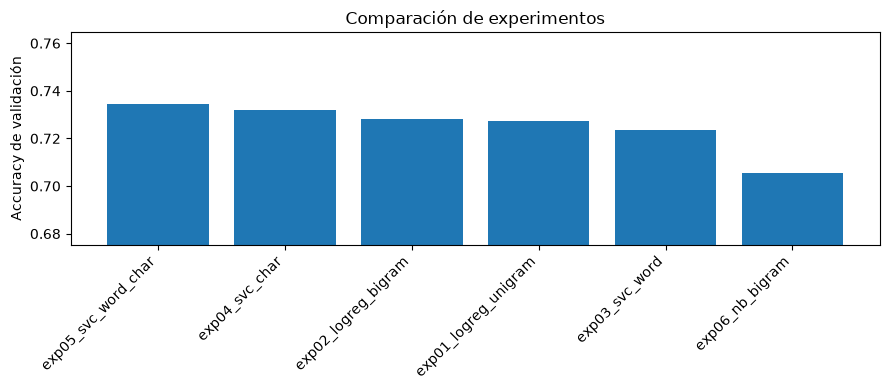

In [68]:
plt.figure(figsize=(9, 4))

plt.bar(
    tabla_resultados["Experimento"],
    tabla_resultados["Accuracy_validación"]
)

plt.ylabel("Accuracy de validación")
plt.title("Comparación de experimentos")
plt.xticks(rotation=45, ha="right")
plt.ylim(
    max(0, tabla_resultados["Accuracy_validación"].min() - 0.03),
    min(1, tabla_resultados["Accuracy_validación"].max() + 0.03)
)
plt.tight_layout()
plt.show()


# 13. Ajuste de hiperparámetros — LinearSVC con TF-IDF de palabras

Además de comparar representaciones, se realiza una búsqueda sistemática de hiperparámetros.

Se exploran:

- `C`: intensidad de regularización de SVM;
- rango de n-gramas;
- frecuencia mínima de aparición.

La búsqueda se hace exclusivamente con datos de entrenamiento mediante validación cruzada.


In [69]:
pipeline_grid = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            lowercase=True,
            sublinear_tf=True
        )
    ),
    (
        "modelo",
        LinearSVC(
            random_state=RANDOM_STATE
        )
    )
])

param_grid = {
    "tfidf__ngram_range": [
        (1, 1),
        (1, 2),
        (1, 3)
    ],
    "tfidf__min_df": [
        1,
        2
    ],
    "modelo__C": [
        0.5,
        1.0,
        2.0
    ]
}

grid = GridSearchCV(
    estimator=pipeline_grid,
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid.best_params_)

print("\nMejor accuracy CV:")
print(round(grid.best_score_, 5))


Fitting 5 folds for each of 18 candidates, totalling 90 fits
Mejores parámetros:
{'modelo__C': 1.0, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 2)}

Mejor accuracy CV:
0.73469


In [70]:
modelo_7 = grid.best_estimator_

pred_7 = modelo_7.predict(X_val)
accuracy_7 = accuracy_score(y_val, pred_7)

resultados.append({
    "Experimento": "exp07_svc_grid",
    "Representación": "TF-IDF palabras optimizado",
    "Modelo": "LinearSVC",
    "Accuracy_validación": accuracy_7
})

modelos["exp07_svc_grid"] = modelo_7

print("Accuracy validación del modelo optimizado:", round(accuracy_7, 5))
print(classification_report(y_val, pred_7))


Accuracy validación del modelo optimizado: 0.72375
              precision    recall  f1-score   support

    negativo       0.61      0.61      0.61       843
     neutral       0.98      1.00      0.99       715
    positivo       0.61      0.61      0.61       842

    accuracy                           0.72      2400
   macro avg       0.73      0.74      0.74      2400
weighted avg       0.72      0.72      0.72      2400



# 14. Tabla final de validación

Se actualiza la comparación incluyendo el modelo optimizado con `GridSearchCV`.


In [71]:
tabla_resultados = pd.DataFrame(resultados)

tabla_resultados = tabla_resultados.sort_values(
    "Accuracy_validación",
    ascending=False
).drop_duplicates(
    subset=["Experimento"],
    keep="last"
).reset_index(drop=True)

display(tabla_resultados)

mejor_nombre_validacion = tabla_resultados.loc[
    0,
    "Experimento"
]

print(
    "Mejor modelo por validación:",
    mejor_nombre_validacion
)


,Experimento,Representación,Modelo,Accuracy_validación
0,exp05_svc_word_char,TF-IDF palabras + caracteres,LinearSVC,0.734583
1,exp04_svc_char,"TF-IDF caracteres (3,5)",LinearSVC,0.732083
2,exp02_logreg_bigram,"TF-IDF palabras (1,2)",LogisticRegression,0.728333
3,exp01_logreg_unigram,"TF-IDF palabras (1,1)",LogisticRegression,0.727500
4,exp03_svc_word,"TF-IDF palabras (1,2)",LinearSVC,0.723750
5,exp07_svc_grid,TF-IDF palabras optimizado,LinearSVC,0.723750
6,exp06_nb_bigram,"TF-IDF palabras (1,2)",MultinomialNB,0.705417


Mejor modelo por validación: exp05_svc_word_char


# 15. Análisis de errores del mejor modelo de validación

La accuracy global no muestra qué clases se confunden entre sí.

Por eso se revisan:

- matriz de confusión;
- reporte por clase;
- ejemplos mal clasificados.


              precision    recall  f1-score   support

    negativo       0.63      0.61      0.62       843
     neutral       0.99      1.00      0.99       715
    positivo       0.62      0.63      0.63       842

    accuracy                           0.73      2400
   macro avg       0.75      0.75      0.75      2400
weighted avg       0.73      0.73      0.73      2400



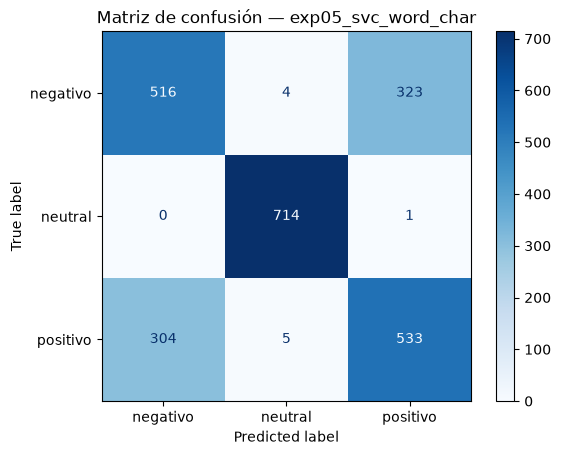

In [72]:
mejor_modelo_val = modelos[mejor_nombre_validacion]

pred_mejor = mejor_modelo_val.predict(X_val)

print(
    classification_report(
        y_val,
        pred_mejor
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_val,
    pred_mejor,
    labels=["negativo", "neutral", "positivo"],
    cmap="Blues"
)

plt.title(
    f"Matriz de confusión — {mejor_nombre_validacion}"
)
plt.show()


In [73]:
errores = pd.DataFrame({
    "texto": X_val.values,
    "real": y_val.values,
    "prediccion": pred_mejor
})

errores = errores[
    errores["real"] != errores["prediccion"]
].reset_index(drop=True)

print("Cantidad de errores:", len(errores))

display(
    errores.sample(
        n=min(20, len(errores)),
        random_state=RANDOM_STATE
    )
)


Cantidad de errores: 637


,texto,real,prediccion
260,"Me llego el lunes por la manana, dos dias despues de pedirlo, en caja sellada. Lo compre para grabar unos audios en la oficina. Para no hacer el cuento largo, para mi la bateri...",negativo,positivo
228,"Se lo acabo de comprar a un familiar hace poco, se lo mande a su casa por paqueteria y llego en una semana mas o menos. El peso es justo lo que estaba buscando. De paso, estoy ...",positivo,negativo
31,"Lo pedi a mediados de mes y me llego en cuatro dias a la casa. La conexion me decepciono de principio a fin. Lo uso principalmente en la oficina, donde lo conecto todos los dia...",positivo,negativo
507,"Hace un mes lo comprí para reemplazar el que tenía antes, llegó a los cuatro días en una caja normal. La cámara quedó pésima para ser honesto, la usé un par de tardes afuera. A...",positivo,negativo
503,"Lo compre hace como dos meses para usarlo ahi en la casa, nomas en la sala y la cocina. El cargador es justo lo que estaba buscando, la neta me llego a la medida. Eso si, la se...",negativo,positivo
30,"Me llegó a mitad de semana, lo pedí un domingo y tardó como tres días en llegar a la casa. La autonomía fue todo un acierto. Lo uso en la oficina casi todos los días desde que ...",positivo,negativo
628,"Lo pedí a principios de mes y llegó en cuatro días. Usa tres pilas AAA, ojo con eso a la hora de tener repuestos en casa. La carcasa luce cómoda para el precio que tiene, la ma...",negativo,positivo
110,Compré este televisor a principios de mes porque la sala estaba pendiente de cambiar el viejo. Lo estrenamos un domingo viendo fútbol con la familia. La resolución se ve precis...,negativo,positivo
247,"Me llegó el smartwatch a los cuatro días de comprarlo, en caja cerrada y con su cable de carga. Llevando un tiempo con él, lo estoy probando a fondo, incluso en la ducha y llov...",negativo,positivo
522,"Hace unos días que lo compré y lo estoy usando nada más en casa, adentro del depto. La calidad me resultó ligera para el precio que tiene, la verdad que pagué como 200 pesos po...",negativo,positivo


### Reflexión sobre errores

Después de ejecutar la celda anterior, revisar manualmente ejemplos y documentar patrones como:

- reseñas con elogios y críticas simultáneas;
- negaciones;
- sarcasmo o ironía;
- textos muy cortos;
- palabras ambiguas;
- diferencia difícil entre `neutral` y las clases polarizadas.

**Completar aquí después de observar los ejemplos.**


# 16. Generación de submissions para Kaggle

El proyecto exige evidencia de al menos **5 envíos diferentes**.

La siguiente celda genera un archivo por experimento dentro de la carpeta `submissions/`.

Cada modelo se vuelve a entrenar usando los **12.000 registros completos de `train.csv`** antes de predecir `eval.csv`.


In [74]:
submissions_generadas = {}

for nombre in tabla_resultados["Experimento"]:
    modelo = modelos[nombre]

    modelo_full, ruta = crear_submission(
        nombre,
        modelo
    )

    submissions_generadas[nombre] = {
        "modelo_full": modelo_full,
        "ruta": ruta
    }

print("\nTotal de submissions generadas:", len(submissions_generadas))


Submission creada: submissions/exp05_svc_word_char.csv


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


Submission creada: submissions/exp04_svc_char.csv


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


Submission creada: submissions/exp02_logreg_bigram.csv


...

Submission creada: submissions/exp07_svc_grid.csv


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


Submission creada: submissions/exp06_nb_bigram.csv


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral



Total de submissions generadas: 7


In [75]:
print("Archivos disponibles para subir a Kaggle:\n")

for nombre, info in submissions_generadas.items():
    print(nombre, "->", info["ruta"])


Archivos disponibles para subir a Kaggle:

exp05_svc_word_char -> submissions/exp05_svc_word_char.csv
exp04_svc_char -> submissions/exp04_svc_char.csv
exp02_logreg_bigram -> submissions/exp02_logreg_bigram.csv
exp01_logreg_unigram -> submissions/exp01_logreg_unigram.csv
exp03_svc_word -> submissions/exp03_svc_word.csv
exp07_svc_grid -> submissions/exp07_svc_grid.csv
exp06_nb_bigram -> submissions/exp06_nb_bigram.csv


# 17. Registrar resultados de Kaggle

Después de subir los archivos a Kaggle, escribir los scores públicos en el diccionario siguiente.

Ejemplo:

```python
scores_kaggle = {
    "exp01_logreg_unigram": 0.71,
    "exp02_logreg_bigram": 0.72,
    ...
}
```

No inventar valores. Copiarlos exactamente del leaderboard.

El modelo final entregado en Bloque Neón debe corresponder al mejor envío del grupo.


In [76]:
# ============================================================
# COMPLETAR DESPUÉS DE SUBIR LOS ARCHIVOS A KAGGLE
# ============================================================

scores_kaggle = {
    "exp01_logreg_unigram": 0.72333,
    "exp02_logreg_bigram": 0.72555,
    "exp03_svc_word": np.nan,
    "exp04_svc_char": 0.74000,
    "exp05_svc_word_char": 0.73555,
    "exp06_nb_bigram": 0.68444,
    "exp07_svc_grid": np.nan
}

tabla_kaggle = tabla_resultados.copy()

tabla_kaggle["Accuracy_Kaggle"] = (
    tabla_kaggle["Experimento"]
    .map(scores_kaggle)
)

display(tabla_kaggle)


,Experimento,Representación,Modelo,Accuracy_validación,Accuracy_Kaggle
0,exp05_svc_word_char,TF-IDF palabras + caracteres,LinearSVC,0.734583,0.73555
1,exp04_svc_char,"TF-IDF caracteres (3,5)",LinearSVC,0.732083,0.74000
2,exp02_logreg_bigram,"TF-IDF palabras (1,2)",LogisticRegression,0.728333,0.72555
3,exp01_logreg_unigram,"TF-IDF palabras (1,1)",LogisticRegression,0.727500,0.72333
4,exp03_svc_word,"TF-IDF palabras (1,2)",LinearSVC,0.723750,NaN
5,exp07_svc_grid,TF-IDF palabras optimizado,LinearSVC,0.723750,NaN
6,exp06_nb_bigram,"TF-IDF palabras (1,2)",MultinomialNB,0.705417,0.68444


# 18. Selección del modelo final

La lógica es:

1. Si ya se registraron scores de Kaggle, se selecciona el mejor score público.
2. Si todavía no se han registrado, se usa provisionalmente el mejor modelo de validación.

**Antes de la entrega final se deben llenar los scores de Kaggle y volver a ejecutar esta sección.**


In [77]:
scores_validos = {
    nombre: score
    for nombre, score in scores_kaggle.items()
    if pd.notna(score)
}

if len(scores_validos) > 0:
    NOMBRE_MODELO_FINAL = max(
        scores_validos,
        key=scores_validos.get
    )

    print(
        "Modelo final seleccionado por Kaggle:",
        NOMBRE_MODELO_FINAL
    )

    print(
        "Score público:",
        scores_validos[NOMBRE_MODELO_FINAL]
    )

else:
    NOMBRE_MODELO_FINAL = mejor_nombre_validacion

    print(
        "AÚN NO HAY SCORES DE KAGGLE."
    )

    print(
        "Se usa provisionalmente el mejor modelo de validación:",
        NOMBRE_MODELO_FINAL
    )


Modelo final seleccionado por Kaggle: exp04_svc_char
Score público: 0.74


# 19. Reentrenamiento y guardado del modelo final

El pipeline final se entrena con **todo `train.csv`** y se guarda con `joblib`.

Como el pipeline incluye la vectorización TF-IDF y el clasificador, el archivo guardado contiene todo lo necesario para reproducir predicciones.


In [78]:
modelo_base_final = modelos[
    NOMBRE_MODELO_FINAL
]

modelo_final = clone(
    modelo_base_final
)

modelo_final.fit(
    X,
    y
)

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

MODEL_PATH = (
    MODELS_DIR /
    "modelo_final_santiago.joblib"
)

joblib.dump(
    modelo_final,
    MODEL_PATH
)

print(
    "Modelo guardado en:",
    MODEL_PATH
)


Modelo guardado en: models/modelo_final_santiago.joblib


# 20. Submission final

Se genera nuevamente el archivo correspondiente al modelo seleccionado para asegurar que coincida exactamente con el modelo guardado.


In [79]:
pred_final = modelo_final.predict(
    eval_df["text"]
    .fillna("")
    .astype(str)
)

submission_final = pd.DataFrame({
    "id": eval_df["id"],
    "answer": pred_final
})

assert len(submission_final) == len(eval_df)
assert submission_final["id"].is_unique
assert submission_final["answer"].isin(
    ["negativo", "neutral", "positivo"]
).all()

SUBMISSION_FINAL_PATH = Path(
    "submission_FINAL.csv"
)

submission_final.to_csv(
    SUBMISSION_FINAL_PATH,
    index=False
)

print(
    "Submission final:",
    SUBMISSION_FINAL_PATH
)

display(submission_final.head())


Submission final: submission_FINAL.csv


,id,answer
0,0,neutral
1,1,positivo
2,2,neutral
3,3,neutral
4,4,neutral


# 21. Verificación de reproducibilidad

Se vuelve a cargar el archivo `joblib` y se comprueba que produzca predicciones válidas.


In [80]:
modelo_cargado = joblib.load(
    MODEL_PATH
)

pred_prueba = modelo_cargado.predict(
    eval_df["text"]
    .fillna("")
    .astype(str)
    .head(5)
)

print("Predicciones de prueba:")
print(pred_prueba)


Predicciones de prueba:
['neutral' 'positivo' 'neutral' 'neutral' 'neutral']


# 22. Conclusiones

Después de ejecutar todos los experimentos y obtener los resultados de Kaggle, completar:

### Mejor representación
Indicar si funcionó mejor TF-IDF de palabras, caracteres o la combinación.

### Mejor modelo
Indicar cuál clasificador obtuvo mejor desempeño.

### Efecto de los n-gramas
Explicar si incorporar bigramas/trigramas mejoró o no la clasificación.

### Diferencia entre validación local y Kaggle
Comparar el orden de los modelos según validación con el leaderboard público.

### Principales errores
Resumir los patrones encontrados en las reseñas mal clasificadas.

### Limitaciones

Los modelos clásicos basados en TF-IDF representan muy bien la presencia y frecuencia de palabras o secuencias cortas, pero tienen limitaciones para capturar relaciones de largo alcance, ironía, dependencia del orden completo de la oración y contexto semántico profundo.


# 23. Registro del proceso seguido

Esta tabla debe quedar completa al finalizar el proyecto. Sirve como evidencia de iteración.

| Experimento | Cambio principal | Accuracy validación | Accuracy Kaggle | Conclusión |
|---|---|---:|---:|---|
| exp01 | TF-IDF unigramas + Logistic | completar | completar | completar |
| exp02 | Agregar bigramas | completar | completar | completar |
| exp03 | Cambiar a LinearSVC | completar | completar | completar |
| exp04 | Usar n-gramas de caracteres | completar | completar | completar |
| exp05 | Combinar palabras + caracteres | completar | completar | completar |
| exp06 | Comparar Naive Bayes | completar | completar | completar |
| exp07 | GridSearchCV | completar | completar | completar |

La versión final del notebook debe explicar por qué se conservaron o descartaron los diferentes enfoques.


# 24. Checklist de entrega — Parte 1

Antes de entregar:

- [ ] Ejecutar el notebook completo desde cero.
- [ ] Confirmar que no haya errores.
- [ ] Generar al menos 5 submissions diferentes.
- [ ] Subir al menos 5 submissions a Kaggle.
- [ ] Registrar los scores de Kaggle en el notebook.
- [ ] Identificar el mejor envío del grupo.
- [ ] Verificar que `NOMBRE_MODELO_FINAL` corresponda a ese envío.
- [ ] Volver a entrenar el modelo final con los 12.000 ejemplos.
- [ ] Generar `submission_FINAL.csv`.
- [ ] Guardar `models/modelo_final_santiago.joblib`.
- [ ] Completar las conclusiones y el registro de experimentos.
- [ ] Guardar todas las salidas visibles en el notebook.
- [ ] Verificar que el notebook sea reproducible.
- [ ] Prepararse para sustentar las decisiones de modelado.


# 25. Preguntas que debemos poder responder en la sustentación

1. ¿Por qué no se usó `eval.csv` para seleccionar modelos?
2. ¿Qué representa TF-IDF?
3. ¿Qué diferencia hay entre unigramas, bigramas y n-gramas de caracteres?
4. ¿Por qué no se eliminaron stopwords?
5. ¿Por qué LinearSVC suele funcionar bien con texto?
6. ¿Qué controla el hiperparámetro `C`?
7. ¿Por qué se utilizó accuracy?
8. ¿Qué modelo funcionó mejor localmente y cuál en Kaggle?
9. ¿Qué clases se confundieron más?
10. ¿Qué limitaciones tiene una representación bolsa-de-palabras/TF-IDF frente a modelos secuenciales?
11. ¿Por qué el modelo final entregado debe ser exactamente el del mejor envío?
12. ¿Cómo se garantiza la reproducibilidad?


# 26. Archivos que deben quedar en el repositorio

Una estructura recomendada es:

```text
proyecto/
├── data/
│   ├── train.csv
│   ├── eval.csv
│   └── sample_submission.csv
│
├── submissions/
│   ├── exp01_logreg_unigram.csv
│   ├── exp02_logreg_bigram.csv
│   ├── ...
│   └── exp07_svc_grid.csv
│
├── models/
│   └── modelo_final_santiago.joblib
│
├── santiagoSerrano_COMPLETO.ipynb
└── submission_FINAL.csv
```

Para exportar el notebook a HTML, si lo necesitan:

```bash
jupyter nbconvert --to html santiagoSerrano_COMPLETO.ipynb
```
